# Multi-output conformal prediction result aggregation

This notebook reads the six result workbooks corresponding to `2 datasets × 3 nonconformity scores`, cleans their two-row Excel headers, and creates the aggregated tables needed for Section 5 of the paper.

Expected file names:

- `SGVehicle-Hinge-results.xlsx`
- `SGVehicle-Margin-results.xlsx`
- `SGVehicle-PIP-results.xlsx`
- `UTKFace-Hinge-results.xlsx`
- `UTKFace-Margin-results.xlsx`
- `UTKFace-PIP-results.xlsx`

The notebook is robust to missing files: it will process all available files and list any missing ones.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Change this if your xlsx files are stored elsewhere.
DATA_DIR = Path('/home/marcs/projects/masters-thesis/results')
OUTPUT_DIR = DATA_DIR / 'aggregated_tables'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['SGVehicle', 'UTKFace']
SCORES = ['Hinge', 'Margin', 'PIP']
EXPECTED_FILES = [DATA_DIR / f'{dataset}-{score}-results.xlsx' for dataset in DATASETS for score in SCORES]

print('Data directory:', DATA_DIR)
print('Output directory:', OUTPUT_DIR)


Data directory: /home/marcs/projects/masters-thesis/results
Output directory: /home/marcs/projects/masters-thesis/results/aggregated_tables


## Helper functions

The Excel files use a two-row header. The first row stores metric groups such as `Overall Eff`, `Overall Inf`, and `Overall CovGap`, while the second row stores `mean` and `std`. The first three columns describe the model/calibration/configuration and are forward-filled because Excel merged cells appear as blanks when read programmatically.


In [2]:
def sanitize_col(text: object) -> str:
    """Convert Excel header text into a compact snake_case column name."""
    text = str(text).strip()
    text = text.replace(' - ', '_').replace('-', '_')
    text = re.sub(r'[^A-Za-z0-9]+', '_', text)
    text = re.sub(r'_+', '_', text).strip('_').lower()
    return text


def parse_dataset_score(path: Path) -> tuple[str, str]:
    """Extract dataset and score from a filename such as SGVehicle-PIP-results.xlsx."""
    stem = path.stem
    pattern = re.compile(r'(?P<dataset>SGVehicle|UTKFace)[-_ ](?P<score>Hinge|Margin|PIP|PiP)[-_ ]results', re.IGNORECASE)
    match = pattern.search(stem)
    if not match:
        raise ValueError(f'Cannot infer dataset/score from filename: {path.name}')
    dataset = match.group('dataset')
    score_raw = match.group('score')
    score = 'PIP' if score_raw.lower() == 'pip' else score_raw.capitalize()
    return dataset, score


def method_from_levels(model_type: str, calibration_type: str) -> str:
    """Map old High/Low labels to paper terminology."""
    model = str(model_type).lower()
    calib = str(calibration_type).lower()
    model_level = 'Taskwise' if 'high' in model else 'Joint'
    calib_level = 'Task-wise' if 'high' in calib else 'Joint'
    if model_level == 'Taskwise' and calib_level == 'Task-wise':
        return 'TT'
    if model_level == 'Taskwise' and calib_level == 'Joint':
        return 'TJ'
    if model_level == 'Joint' and calib_level == 'Task-wise':
        return 'JT'
    if model_level == 'Joint' and calib_level == 'Joint':
        return 'JJ'
    return 'Unknown'


def clean_results_file(path: Path) -> pd.DataFrame:
    """Read one result workbook and return a cleaned long/wide dataframe."""
    dataset, score = parse_dataset_score(path)
    raw = pd.read_excel(path, sheet_name=0, header=None, engine='openpyxl')
    raw = raw.dropna(how='all').dropna(axis=1, how='all')
    
    header0 = raw.iloc[0].ffill()
    header1 = raw.iloc[1]
    cols = []
    for idx, (h0, h1) in enumerate(zip(header0, header1)):
        if idx == 0:
            cols.append('model_type')
        elif idx == 1:
            cols.append('calibration_type')
        elif idx == 2:
            cols.append('conformal_type')
        else:
            metric = sanitize_col(h0)
            stat = sanitize_col(h1)
            cols.append(f'{metric}_{stat}')
    
    df = raw.iloc[2:].copy()
    df.columns = cols
    df[['model_type', 'calibration_type']] = df[['model_type', 'calibration_type']].ffill()
    df = df[df['conformal_type'].notna()].copy()
    
    for col in df.columns:
        if col not in ['model_type', 'calibration_type', 'conformal_type']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df.insert(0, 'dataset', dataset)
    df.insert(1, 'score', score)
    df['model_architecture'] = np.where(df['model_type'].str.contains('High', case=False, na=False), 'Task-wise', 'Joint-output')
    df['calibration_level'] = np.where(df['calibration_type'].str.contains('High', case=False, na=False), 'Task-wise', 'Joint')
    df['method'] = [method_from_levels(m, c) for m, c in zip(df['model_type'], df['calibration_type'])]
    return df


def load_all_results(expected_files=EXPECTED_FILES) -> pd.DataFrame:
    available = [p for p in expected_files if p.exists()]
    missing = [p.name for p in expected_files if not p.exists()]
    if missing:
        print('Missing files:')
        for name in missing:
            print('  -', name)
    if not available:
        raise FileNotFoundError('No expected result workbooks were found.')
    frames = []
    for path in available:
        print('Reading:', path.name)
        frames.append(clean_results_file(path))
    return pd.concat(frames, ignore_index=True)


def summarize(df: pd.DataFrame, group_cols: list[str], metrics: list[str]) -> pd.DataFrame:
    """Aggregate row-level metric means by group.

    Columns ending in `_mean` are means from the workbook rows. The generated `_std` columns below are
    standard deviations across rows in the grouping, not the within-row calibration split std values.
    """
    agg_spec = {}
    for metric in metrics:
        if metric in df.columns:
            agg_spec[f'{metric}_mean'] = (metric, 'mean')
            agg_spec[f'{metric}_std'] = (metric, 'std')
    out = df.groupby(group_cols, dropna=False).agg(**agg_spec, n=('method', 'size')).reset_index()
    return out


def add_reduction_table(summary: pd.DataFrame, level_col='calibration_level', size_col='overall_eff_mean_mean', inf_col='overall_inf_mean_mean', covgap_col='overall_covgap_mean_mean') -> pd.DataFrame:
    """Compute simple task-wise vs joint improvement percentages from a two-row calibration-level summary."""
    s = summary.set_index(level_col)
    rows = []
    if {'Task-wise', 'Joint'}.issubset(s.index):
        joint_size = s.loc['Joint', size_col]
        task_size = s.loc['Task-wise', size_col]
        joint_inf = s.loc['Joint', inf_col]
        task_inf = s.loc['Task-wise', inf_col]
        joint_covgap = s.loc['Joint', covgap_col]
        task_covgap = s.loc['Task-wise', covgap_col]
        rows.append({'Metric': 'AvgSize', 'Joint': joint_size, 'Task-wise': task_size, 'Relative improvement (%)': 100 * (joint_size - task_size) / joint_size})
        rows.append({'Metric': 'Informativeness', 'Joint': joint_inf, 'Task-wise': task_inf, 'Relative improvement (%)': 100 * (task_inf - joint_inf) / abs(joint_inf) if joint_inf != 0 else np.nan})
        rows.append({'Metric': 'CovGap', 'Joint': joint_covgap, 'Task-wise': task_covgap, 'Relative improvement (%)': 100 * (joint_covgap - task_covgap) / joint_covgap})
    return pd.DataFrame(rows)


def save_table(df: pd.DataFrame, name: str) -> None:
    """Save a table as CSV and LaTeX."""
    csv_path = OUTPUT_DIR / f'{name}.csv'
    tex_path = OUTPUT_DIR / f'{name}.tex'
    df.to_csv(csv_path, index=False)
    with open(tex_path, 'w', encoding='utf-8') as f:
        f.write(df.to_latex(index=False, float_format='%.4f'))
    print(f'Saved: {csv_path.name}, {tex_path.name}')


## Load and inspect all result files

In [3]:
results = load_all_results()
print('Loaded rows:', len(results))
print('Datasets:', sorted(results['dataset'].unique()))
print('Scores:', sorted(results['score'].unique()))
print('Methods:', sorted(results['method'].unique()))

# Main metric columns used for aggregation.
METRICS = [
    'overall_eff_mean',
    'overall_inf_mean',
    'overall_covgap_mean',
]

# Include coverage automatically if your future workbooks contain it.
optional_coverage_cols = [c for c in results.columns if c in ['overall_cov_mean', 'overall_coverage_mean', 'coverage_mean']]
METRICS_WITH_COVERAGE = optional_coverage_cols + METRICS

display(results.head(10))


Reading: SGVehicle-Hinge-results.xlsx
Reading: SGVehicle-Margin-results.xlsx
Reading: SGVehicle-PIP-results.xlsx
Reading: UTKFace-Hinge-results.xlsx
Reading: UTKFace-Margin-results.xlsx
Reading: UTKFace-PIP-results.xlsx
Loaded rows: 96
Datasets: ['SGVehicle', 'UTKFace']
Scores: ['Hinge', 'Margin', 'PIP']
Methods: ['JJ', 'JT', 'TJ', 'TT']


,dataset,score,model_type,calibration_type,conformal_type,overall_eff_mean,overall_eff_std,overall_inf_mean,overall_inf_std,overall_covgap_mean,overall_covgap_std,0_task_eff_mean,0_task_eff_std,0_task_inf_mean,0_task_inf_std,0_task_covgap_mean,0_task_covgap_std,1_task_eff_mean,1_task_eff_std,1_task_inf_mean,1_task_inf_std,1_task_covgap_mean,1_task_covgap_std,model_architecture,calibration_level,method
0,SGVehicle,Hinge,High Model,High Calibration,Standard Global,1.3336,0.0141,0.7254,0.0097,7.6056,0.2822,1.1663,0.0077,0.8401,0.0069,3.4295,0.1927,1.1424,0.0059,0.8632,0.0046,3.4033,0.3356,Task-wise,Task-wise,TT
1,SGVehicle,Hinge,High Model,High Calibration,Standard Taskwise,1.3367,0.0157,0.7231,0.0120,7.6639,0.3631,1.2039,0.0106,0.8092,0.0083,3.0362,0.1815,1.1086,0.0084,0.8928,0.0080,3.5489,0.3855,Task-wise,Task-wise,TT
2,SGVehicle,Hinge,High Model,High Calibration,Classwise,1.5286,0.0297,0.6204,0.0125,5.6263,0.4793,1.2876,0.0160,0.7401,0.0100,1.6148,0.2166,1.1844,0.0228,0.8355,0.0177,1.8489,0.1930,Task-wise,Task-wise,TT
3,SGVehicle,Hinge,High Model,High Calibration,Clustered Taskwise,1.4298,0.0196,0.6660,0.0111,7.1954,0.3629,1.2857,0.0153,0.7422,0.0104,1.6716,0.1375,1.1086,0.0084,0.8928,0.0080,3.5489,0.3855,Task-wise,Task-wise,TT
4,SGVehicle,Hinge,High Model,High Calibration,Clustered Global,1.5286,0.0297,0.6204,0.0125,5.6263,0.4793,1.2876,0.0160,0.7401,0.0100,1.6148,0.2166,1.1844,0.0228,0.8355,0.0177,1.8489,0.1930,Task-wise,Task-wise,TT
5,SGVehicle,Hinge,High Model,Low Calibration,Standard,1.7587,0.0229,0.4700,0.0062,5.0357,0.2524,1.3944,0.0128,0.6837,0.0075,2.6100,0.0548,1.3412,0.0110,0.7192,0.0053,3.3422,0.2578,Task-wise,Joint,TJ
6,SGVehicle,Hinge,High Model,Low Calibration,Classwise,53.9209,0.0464,0.0000,0.0000,4.0710,0.1299,12.0000,0.0000,0.0000,0.0000,5.0000,0.0000,6.2982,0.0267,0.0000,0.0000,4.0929,0.0900,Task-wise,Joint,TJ
7,SGVehicle,Hinge,High Model,Low Calibration,Clustered,2.1481,0.0536,0.3872,0.0140,4.5295,0.1465,1.6239,0.0343,0.5704,0.0096,2.9185,0.2340,1.4860,0.0292,0.6463,0.0153,3.0305,0.1510,Task-wise,Joint,TJ
8,SGVehicle,Hinge,Low Model,High Calibration,Standard Global,1.5681,0.0208,0.6000,0.0117,8.1825,0.4914,1.2536,0.0103,0.7616,0.0087,2.8325,0.1252,1.2420,0.0079,0.7761,0.0065,4.6387,0.2498,Joint-output,Task-wise,JT
9,SGVehicle,Hinge,Low Model,High Calibration,Standard Taskwise,1.5723,0.0210,0.5986,0.0114,8.3317,0.5825,1.2426,0.0116,0.7707,0.0098,2.9361,0.1231,1.2563,0.0087,0.7655,0.0071,4.5659,0.2996,Joint-output,Task-wise,JT


# 5.1 Effect of Calibration Granularity

This table answers the main paper question: **does task-wise calibration outperform joint calibration?**

Aggregation: average over datasets, nonconformity scores, predictive architectures, and calibration strategies, while keeping only the calibration level.

In [4]:
tbl_51_calibration_granularity = summarize(results, ['calibration_level'], METRICS_WITH_COVERAGE)
display(tbl_51_calibration_granularity)
save_table(tbl_51_calibration_granularity, 'table_5_1_effect_of_calibration_granularity')

improvement_51 = add_reduction_table(tbl_51_calibration_granularity)
display(improvement_51)
save_table(improvement_51, 'table_5_1_taskwise_vs_joint_relative_improvement')


,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,Joint,19.6831,23.2704,0.2306,0.1762,3.4107,1.4112,36
1,Task-wise,2.6823,0.8476,0.4543,0.1935,6.7894,1.5671,60


Saved: table_5_1_effect_of_calibration_granularity.csv, table_5_1_effect_of_calibration_granularity.tex


,Metric,Joint,Task-wise,Relative improvement (%)
0,AvgSize,19.6831,2.6823,86.3728
1,Informativeness,0.2306,0.4543,96.9812
2,CovGap,3.4107,6.7894,-99.0622


Saved: table_5_1_taskwise_vs_joint_relative_improvement.csv, table_5_1_taskwise_vs_joint_relative_improvement.tex


# 5.2 Coverage Validity and Calibration Quality

This table focuses on calibration quality. Because the source workbooks currently contain `CovGap` but not raw empirical coverage, the table reports classwise coverage gap. If future files contain empirical coverage, the notebook will include it automatically.

Aggregation: average over datasets, scores, and calibration strategies, while keeping the four architecture--calibration paradigms.

In [5]:
coverage_metrics = optional_coverage_cols + ['overall_covgap_mean']
tbl_52_coverage_quality = summarize(results, ['method', 'model_architecture', 'calibration_level'], coverage_metrics)
display(tbl_52_coverage_quality)
save_table(tbl_52_coverage_quality, 'table_5_2_coverage_validity_and_calibration_quality')

# Optional dataset-level view for text support.
tbl_52_by_dataset = summarize(results, ['dataset', 'calibration_level'], coverage_metrics)
display(tbl_52_by_dataset)
save_table(tbl_52_by_dataset, 'table_5_2_coverage_quality_by_dataset')


,method,model_architecture,calibration_level,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,JJ,Joint-output,Joint,3.4318,1.5011,18
1,JT,Joint-output,Task-wise,6.8106,1.6936,30
2,TJ,Task-wise,Joint,3.3895,1.3587,18
3,TT,Task-wise,Task-wise,6.7681,1.4585,30


Saved: table_5_2_coverage_validity_and_calibration_quality.csv, table_5_2_coverage_validity_and_calibration_quality.tex


,dataset,calibration_level,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,SGVehicle,Joint,4.4268,0.3783,18
1,SGVehicle,Task-wise,6.8415,0.8650,30
2,UTKFace,Joint,2.3946,1.3307,18
3,UTKFace,Task-wise,6.7373,2.0598,30


Saved: table_5_2_coverage_quality_by_dataset.csv, table_5_2_coverage_quality_by_dataset.tex


# 5.3 Efficiency and Informativeness Analysis

This table supports the claim that task-wise calibration gives smaller and more informative final multi-output prediction regions.

Aggregation: average over datasets, scores, and calibration variants, while keeping the four paradigms.

In [6]:
tbl_53_eff_inf = summarize(results, ['method', 'model_architecture', 'calibration_level'], ['overall_eff_mean', 'overall_inf_mean'])
display(tbl_53_eff_inf)
save_table(tbl_53_eff_inf, 'table_5_3_efficiency_and_informativeness')

# A more compact two-row table for the main paper.
tbl_53_eff_inf_by_calib = summarize(results, ['calibration_level'], ['overall_eff_mean', 'overall_inf_mean'])
display(tbl_53_eff_inf_by_calib)
save_table(tbl_53_eff_inf_by_calib, 'table_5_3_efficiency_and_informativeness_by_calibration_level')


,method,model_architecture,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,n
0,JJ,Joint-output,Joint,20.9160,24.3784,0.2323,0.1564,18
1,JT,Joint-output,Task-wise,2.8397,0.8121,0.4348,0.1663,30
2,TJ,Task-wise,Joint,18.4502,22.7455,0.2290,0.1986,18
3,TT,Task-wise,Task-wise,2.5248,0.8665,0.4739,0.2186,30


Saved: table_5_3_efficiency_and_informativeness.csv, table_5_3_efficiency_and_informativeness.tex


,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,n
0,Joint,19.6831,23.2704,0.2306,0.1762,36
1,Task-wise,2.6823,0.8476,0.4543,0.1935,60


Saved: table_5_3_efficiency_and_informativeness_by_calibration_level.csv, table_5_3_efficiency_and_informativeness_by_calibration_level.tex


# 5.4 Effect of Nonconformity Scores

This table tests whether the result is robust to the score choice.

Aggregation: average over datasets, predictive architectures, and calibration strategies, while keeping score and calibration level.

In [7]:
tbl_54_scores = summarize(results, ['score', 'calibration_level'], METRICS)
display(tbl_54_scores)
save_table(tbl_54_scores, 'table_5_4_effect_of_nonconformity_scores')

# Optional: dataset-specific score robustness table.
tbl_54_scores_by_dataset = summarize(results, ['dataset', 'score', 'calibration_level'], METRICS)
display(tbl_54_scores_by_dataset)
save_table(tbl_54_scores_by_dataset, 'table_5_4_effect_of_nonconformity_scores_by_dataset')


,score,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,Hinge,Joint,11.7038,19.8257,0.1791,0.1516,3.5885,1.5732,12
1,Hinge,Task-wise,2.3568,0.8396,0.4224,0.2084,7.0029,1.8694,20
2,Margin,Joint,25.9440,25.6054,0.2566,0.1960,3.2724,1.3781,12
3,Margin,Task-wise,2.9991,0.7759,0.4703,0.1886,6.6675,1.3611,20
4,PIP,Joint,21.4015,23.6402,0.2563,0.1817,3.3712,1.3805,12
5,PIP,Task-wise,2.6908,0.8407,0.4702,0.1890,6.6978,1.4854,20


Saved: table_5_4_effect_of_nonconformity_scores.csv, table_5_4_effect_of_nonconformity_scores.tex


,dataset,score,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,SGVehicle,Hinge,Joint,19.4838,26.8221,0.2430,0.2001,4.6404,0.5649,6
1,SGVehicle,Hinge,Task-wise,1.5566,0.1683,0.6178,0.0704,7.0013,1.0998,10
2,SGVehicle,Margin,Joint,45.6858,22.5168,0.2563,0.2829,4.3006,0.1723,6
3,SGVehicle,Margin,Task-wise,2.5063,0.8410,0.6341,0.0890,6.7558,0.6600,10
4,SGVehicle,PIP,Joint,37.0181,25.3802,0.2566,0.2662,4.3395,0.2339,6
5,SGVehicle,PIP,Task-wise,1.9812,0.5851,0.6425,0.0695,6.7674,0.8505,10
6,UTKFace,Hinge,Joint,3.9238,0.1833,0.1151,0.0262,2.5366,1.5716,6
7,UTKFace,Hinge,Task-wise,3.1571,0.1914,0.2271,0.0439,7.0045,2.4836,10
8,UTKFace,Margin,Joint,6.2022,0.1575,0.2568,0.0669,2.2441,1.2692,6
9,UTKFace,Margin,Task-wise,3.4919,0.1545,0.3065,0.0871,6.5792,1.8596,10


Saved: table_5_4_effect_of_nonconformity_scores_by_dataset.csv, table_5_4_effect_of_nonconformity_scores_by_dataset.tex


# 5.5 Effect of Predictive Architecture

This table checks whether the calibration level has a stronger effect than the predictive architecture.

Aggregation: average over datasets, scores, and calibration variants, while keeping predictive architecture and calibration level.

In [8]:
tbl_55_architecture = summarize(results, ['model_architecture', 'calibration_level', 'method'], METRICS)
display(tbl_55_architecture)
save_table(tbl_55_architecture, 'table_5_5_effect_of_predictive_architecture')

# Pairwise differences useful for text: same architecture, different calibration.
def pairwise_calibration_effects(df: pd.DataFrame) -> pd.DataFrame:
    base = summarize(df, ['model_architecture', 'calibration_level'], ['overall_eff_mean', 'overall_inf_mean', 'overall_covgap_mean'])
    rows = []
    for arch, g in base.groupby('model_architecture'):
        s = g.set_index('calibration_level')
        if {'Task-wise', 'Joint'}.issubset(s.index):
            rows.append({
                'model_architecture': arch,
                'avgsize_joint_minus_taskwise': s.loc['Joint', 'overall_eff_mean_mean'] - s.loc['Task-wise', 'overall_eff_mean_mean'],
                'informativeness_taskwise_minus_joint': s.loc['Task-wise', 'overall_inf_mean_mean'] - s.loc['Joint', 'overall_inf_mean_mean'],
                'covgap_joint_minus_taskwise': s.loc['Joint', 'overall_covgap_mean_mean'] - s.loc['Task-wise', 'overall_covgap_mean_mean'],
            })
    return pd.DataFrame(rows)

calib_effects_by_arch = pairwise_calibration_effects(results)
display(calib_effects_by_arch)
save_table(calib_effects_by_arch, 'table_5_5_pairwise_calibration_effects_by_architecture')


,model_architecture,calibration_level,method,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,Joint-output,Joint,JJ,20.9160,24.3784,0.2323,0.1564,3.4318,1.5011,18
1,Joint-output,Task-wise,JT,2.8397,0.8121,0.4348,0.1663,6.8106,1.6936,30
2,Task-wise,Joint,TJ,18.4502,22.7455,0.2290,0.1986,3.3895,1.3587,18
3,Task-wise,Task-wise,TT,2.5248,0.8665,0.4739,0.2186,6.7681,1.4585,30


Saved: table_5_5_effect_of_predictive_architecture.csv, table_5_5_effect_of_predictive_architecture.tex


,model_architecture,avgsize_joint_minus_taskwise,informativeness_taskwise_minus_joint,covgap_joint_minus_taskwise
0,Joint-output,18.0763,0.2025,-3.3788
1,Task-wise,15.9254,0.2449,-3.3786


Saved: table_5_5_pairwise_calibration_effects_by_architecture.csv, table_5_5_pairwise_calibration_effects_by_architecture.tex


# Dataset-specific summary tables

These are useful if you want one compact table for SGVehicle and one compact table for UTKFace in the main paper or appendix.

In [9]:
tbl_dataset_method = summarize(results, ['dataset', 'method', 'model_architecture', 'calibration_level'], METRICS)
display(tbl_dataset_method)
save_table(tbl_dataset_method, 'table_dataset_method_summary')

tbl_dataset_calib = summarize(results, ['dataset', 'calibration_level'], METRICS)
display(tbl_dataset_calib)
save_table(tbl_dataset_calib, 'table_dataset_calibration_summary')


,dataset,method,model_architecture,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,SGVehicle,JJ,Joint-output,Joint,36.5023,26.7412,0.2437,0.2139,4.5040,0.4405,9
1,SGVehicle,JT,Joint-output,Task-wise,2.2940,0.8245,0.5851,0.0582,6.8940,0.9973,15
2,SGVehicle,TJ,Task-wise,Joint,31.6228,26.6067,0.2603,0.2711,4.3496,0.3109,9
3,SGVehicle,TT,Task-wise,Task-wise,1.7354,0.4116,0.6778,0.0602,6.7889,0.7412,15
4,UTKFace,JJ,Joint-output,Joint,5.3297,1.0981,0.2209,0.0769,2.3597,1.4170,9
5,UTKFace,JT,Joint-output,Task-wise,3.3854,0.2197,0.2845,0.0740,6.7272,2.2208,15
6,UTKFace,TJ,Task-wise,Joint,5.2776,1.0249,0.1977,0.0901,2.4294,1.3237,9
7,UTKFace,TT,Task-wise,Task-wise,3.3143,0.2249,0.2699,0.0788,6.7474,1.9637,15


Saved: table_dataset_method_summary.csv, table_dataset_method_summary.tex


,dataset,calibration_level,overall_eff_mean_mean,overall_eff_mean_std,overall_inf_mean_mean,overall_inf_mean_std,overall_covgap_mean_mean,overall_covgap_mean_std,n
0,SGVehicle,Joint,34.0626,25.9991,0.2520,0.2371,4.4268,0.3783,18
1,SGVehicle,Task-wise,2.0147,0.7005,0.6314,0.0749,6.8415,0.8650,30
2,UTKFace,Joint,5.3037,1.0308,0.2093,0.0821,2.3946,1.3307,18
3,UTKFace,Task-wise,3.3498,0.2214,0.2772,0.0755,6.7373,2.0598,30


Saved: table_dataset_calibration_summary.csv, table_dataset_calibration_summary.tex


# Appendix tables: cleaned detailed results

These tables preserve every row from the original workbooks while using consistent column names and method abbreviations. They are suitable for Appendix A.

In [10]:
detail_cols = [
    'dataset', 'score', 'method', 'model_architecture', 'calibration_level', 'conformal_type',
    'overall_eff_mean', 'overall_eff_std',
    'overall_inf_mean', 'overall_inf_std',
    'overall_covgap_mean', 'overall_covgap_std',
]
# Include task-specific metrics if present.
task_cols = [c for c in results.columns if re.match(r'^[01]_task_(eff|inf|covgap)_(mean|std)$', c)]
appendix_cols = [c for c in detail_cols + task_cols if c in results.columns]
appendix_detail = results[appendix_cols].copy()

display(appendix_detail)
save_table(appendix_detail, 'appendix_detailed_clean_results')


,dataset,score,method,model_architecture,calibration_level,conformal_type,overall_eff_mean,overall_eff_std,overall_inf_mean,overall_inf_std,overall_covgap_mean,overall_covgap_std,0_task_eff_mean,0_task_eff_std,0_task_inf_mean,0_task_inf_std,0_task_covgap_mean,0_task_covgap_std,1_task_eff_mean,1_task_eff_std,1_task_inf_mean,1_task_inf_std,1_task_covgap_mean,1_task_covgap_std
0,SGVehicle,Hinge,TT,Task-wise,Task-wise,Standard Global,1.3336,0.0141,0.7254,0.0097,7.6056,0.2822,1.1663,0.0077,0.8401,0.0069,3.4295,0.1927,1.1424,0.0059,0.8632,0.0046,3.4033,0.3356
1,SGVehicle,Hinge,TT,Task-wise,Task-wise,Standard Taskwise,1.3367,0.0157,0.7231,0.0120,7.6639,0.3631,1.2039,0.0106,0.8092,0.0083,3.0362,0.1815,1.1086,0.0084,0.8928,0.0080,3.5489,0.3855
2,SGVehicle,Hinge,TT,Task-wise,Task-wise,Classwise,1.5286,0.0297,0.6204,0.0125,5.6263,0.4793,1.2876,0.0160,0.7401,0.0100,1.6148,0.2166,1.1844,0.0228,0.8355,0.0177,1.8489,0.1930
3,SGVehicle,Hinge,TT,Task-wise,Task-wise,Clustered Taskwise,1.4298,0.0196,0.6660,0.0111,7.1954,0.3629,1.2857,0.0153,0.7422,0.0104,1.6716,0.1375,1.1086,0.0084,0.8928,0.0080,3.5489,0.3855
4,SGVehicle,Hinge,TT,Task-wise,Task-wise,Clustered Global,1.5286,0.0297,0.6204,0.0125,5.6263,0.4793,1.2876,0.0160,0.7401,0.0100,1.6148,0.2166,1.1844,0.0228,0.8355,0.0177,1.8489,0.1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,UTKFace,PIP,JT,Joint-output,Task-wise,Clustered Taskwise,3.5623,0.0785,0.2467,0.0221,4.9669,0.3565,1.1597,0.0128,0.8403,0.0128,0.5201,0.3094,3.0310,0.0524,0.2757,0.0255,0.8638,0.1472
92,UTKFace,PIP,JT,Joint-output,Task-wise,Clustered Global,3.5623,0.0785,0.2467,0.0221,4.9669,0.3565,1.1597,0.0128,0.8403,0.0128,0.5201,0.3094,3.0310,0.0524,0.2757,0.0255,0.8638,0.1472
93,UTKFace,PIP,JJ,Joint-output,Joint,Standard,5.7186,0.1433,0.3100,0.0116,4.1940,0.5184,1.5721,0.0155,0.4279,0.0155,3.7704,0.1544,3.2243,0.0591,0.3579,0.0119,3.8301,0.4403
94,UTKFace,PIP,JJ,Joint-output,Joint,Classwise,5.8973,0.1041,0.2409,0.0120,1.3895,0.2052,1.7069,0.0116,0.2931,0.0116,4.0244,0.1215,3.4811,0.0276,0.2432,0.0127,1.5124,0.2908


Saved: appendix_detailed_clean_results.csv, appendix_detailed_clean_results.tex


# Optional figures

The following plots are optional, but useful for the main paper. They visualize the same aggregated tables.

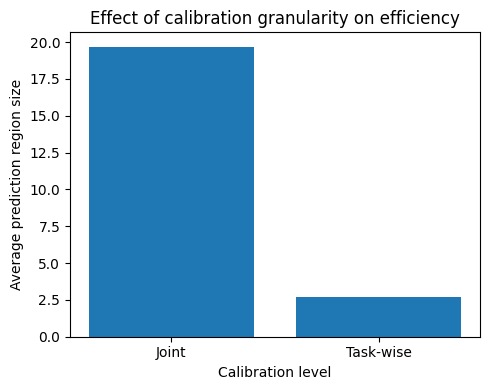

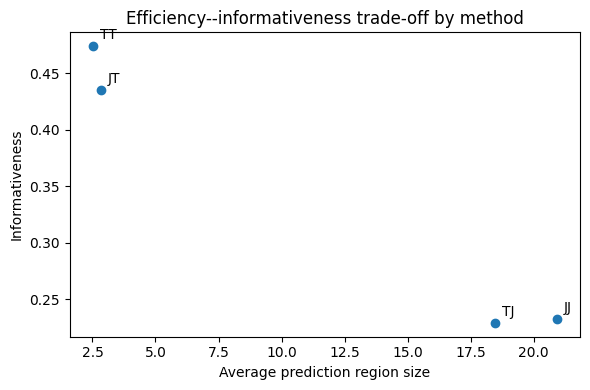

In [11]:
import matplotlib.pyplot as plt

# Figure 1: AvgSize by calibration level.
fig_df = tbl_51_calibration_granularity.copy()
plt.figure(figsize=(5, 4))
plt.bar(fig_df['calibration_level'], fig_df['overall_eff_mean_mean'])
plt.ylabel('Average prediction region size')
plt.xlabel('Calibration level')
plt.title('Effect of calibration granularity on efficiency')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_avgsize_by_calibration_level.png', dpi=300)
plt.show()

# Figure 2: Method-level efficiency/informativeness tradeoff.
plot_df = summarize(results, ['method'], ['overall_eff_mean', 'overall_inf_mean', 'overall_covgap_mean'])
plt.figure(figsize=(6, 4))
plt.scatter(plot_df['overall_eff_mean_mean'], plot_df['overall_inf_mean_mean'])
for _, row in plot_df.iterrows():
    plt.annotate(row['method'], (row['overall_eff_mean_mean'], row['overall_inf_mean_mean']), textcoords='offset points', xytext=(5, 5))
plt.xlabel('Average prediction region size')
plt.ylabel('Informativeness')
plt.title('Efficiency--informativeness trade-off by method')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_efficiency_informativeness_tradeoff.png', dpi=300)
plt.show()


# Export all aggregated tables to one Excel workbook

This makes it easy to review the generated tables outside the notebook.

In [12]:
excel_path = OUTPUT_DIR / 'all_aggregated_tables.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    tbl_51_calibration_granularity.to_excel(writer, sheet_name='5.1 Calibration', index=False)
    improvement_51.to_excel(writer, sheet_name='5.1 Improvement', index=False)
    tbl_52_coverage_quality.to_excel(writer, sheet_name='5.2 Coverage', index=False)
    tbl_53_eff_inf.to_excel(writer, sheet_name='5.3 EffInf', index=False)
    tbl_54_scores.to_excel(writer, sheet_name='5.4 Scores', index=False)
    tbl_55_architecture.to_excel(writer, sheet_name='5.5 Architecture', index=False)
    calib_effects_by_arch.to_excel(writer, sheet_name='5.5 Pairwise', index=False)
    tbl_dataset_method.to_excel(writer, sheet_name='Dataset Method', index=False)
    appendix_detail.to_excel(writer, sheet_name='Appendix Detail', index=False)
print('Saved aggregated workbook:', excel_path)


Saved aggregated workbook: /home/marcs/projects/masters-thesis/results/aggregated_tables/all_aggregated_tables.xlsx
